# CSC528 Assignment 3 — Problem 1

## Image Segmentation via a Gaussian Mixture Model fit with Expectation Maximization

**Author:** Asad Khan  
**Course:** CSC528 — Computer Vision

---

## 1. Introduction

The goal of this experiment is to segment a grayscale image by modeling its intensity histogram as a mixture of $K$ Gaussian distributions and fitting the mixture parameters with the Expectation Maximization (EM) algorithm. Each pixel is then assigned to the Gaussian component under which it has the highest posterior probability, producing a label image that partitions the input into $K$ regions. Following the assignment specification, no machine-learning libraries are used; the EM update equations are implemented from scratch using only NumPy. Spatial information is intentionally ignored — we treat the image as an unordered bag of intensities, so this is exactly a one-dimensional GMM fit to the image histogram.

## 2. Method

### 2.1 Gaussian mixture model

Given pixel intensities $x_1, \ldots, x_N$, we model their distribution as

$$
p(x \mid \Theta) \;=\; \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \sigma_k^2),
$$

where $\pi_k$ are the mixture weights ($\sum_k \pi_k = 1$), and $\mathcal{N}(x\mid\mu_k,\sigma_k^2)$ is a univariate Gaussian. The parameter set is $\Theta = \{\pi_k, \mu_k, \sigma_k^2\}_{k=1}^K$.

### 2.2 Expectation Maximization

Direct maximum-likelihood estimation for a mixture is intractable because of the unknown component assignments. EM introduces latent responsibilities $\gamma_{ik} = P(z_i = k \mid x_i, \Theta)$ and alternates two steps until convergence.

**E-step** — given current parameters, compute the posterior probability that pixel $i$ was generated by component $k$:

$$
\gamma_{ik} \;=\; \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \sigma_k^2)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \sigma_j^2)}.
$$

**M-step** — re-estimate parameters using the responsibilities as soft assignments. Letting $N_k = \sum_i \gamma_{ik}$,

$$
\mu_k \;=\; \frac{1}{N_k}\sum_i \gamma_{ik}\, x_i, \qquad
\sigma_k^2 \;=\; \frac{1}{N_k}\sum_i \gamma_{ik}\,(x_i - \mu_k)^2, \qquad
\pi_k \;=\; \frac{N_k}{N}.
$$

EM is guaranteed to monotonically increase the data log-likelihood at each iteration and converges to a (local) maximum.

### 2.3 Pixel labeling

After convergence, each pixel is given a hard label by maximum a posteriori assignment, $\hat{z}_i = \arg\max_k \gamma_{ik}$. The resulting label map is rendered as a grayscale image, scaling labels uniformly across the $[0, 255]$ range so the segments are visually distinct.


In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load grayscale image
image = cv2.imread("image.jpg", cv2.IMREAD_GRAYSCALE)
assert image is not None, "image.jpg not found in this folder"

# Flatten image into 1D array
pixels = image.flatten().astype(np.float64)

# Number of Gaussians
K = 2

# Initialize parameters
np.random.seed(0)

means = np.random.choice(pixels, K)
variances = np.full(K, 500.0)
weights = np.full(K, 1 / K)

In [11]:
# Gaussian PDF
def gaussian(x, mean, var):
    return (1 / np.sqrt(2 * np.pi * var)) * \
           np.exp(-(x - mean) ** 2 / (2 * var))

# EM Algorithm
max_iterations = 50

for i in range(max_iterations):

    prev_means = means.copy()

    # E-step
    responsibilities = np.zeros((len(pixels), K))

    for k in range(K):
        responsibilities[:, k] = (
            weights[k] *
            gaussian(pixels, means[k], variances[k])
        )

    sums = responsibilities.sum(axis=1, keepdims=True)
    responsibilities /= (sums + 1e-10)

    # M-step
    Nk = responsibilities.sum(axis=0)

    for k in range(K):

        means[k] = np.sum(
            responsibilities[:, k] * pixels
        ) / Nk[k]

        variances[k] = np.sum(
            responsibilities[:, k] *
            (pixels - means[k]) ** 2
        ) / Nk[k]

        variances[k] += 1e-5

        weights[k] = Nk[k] / len(pixels)

    # Convergence check
    if np.allclose(means, prev_means, atol=1e-3):
        print(f"Converged at iteration {i}")
        break

print("means:", means)
print("variances:", variances)
print("weights:", weights)

Converged at iteration 17
means: [136.37534601  20.69243033]
variances: [5361.14147842   81.00639285]
weights: [0.2098617  0.79013827]


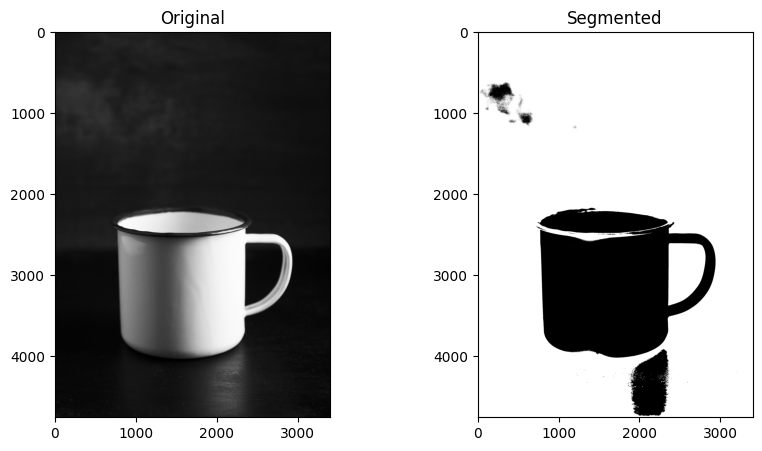

In [12]:
# Assign each pixel to best Gaussian
labels = np.argmax(responsibilities, axis=1)

# Convert labels back to image
segmented = (labels * (255 // (K - 1))).reshape(image.shape).astype(np.uint8)

# Display
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Segmented")
plt.imshow(segmented, cmap='gray')

plt.show()